WARNING *** file size (2629504) not 512 + multiple of sector size (512)
WARNING *** file size (9789312) not 512 + multiple of sector size (512)


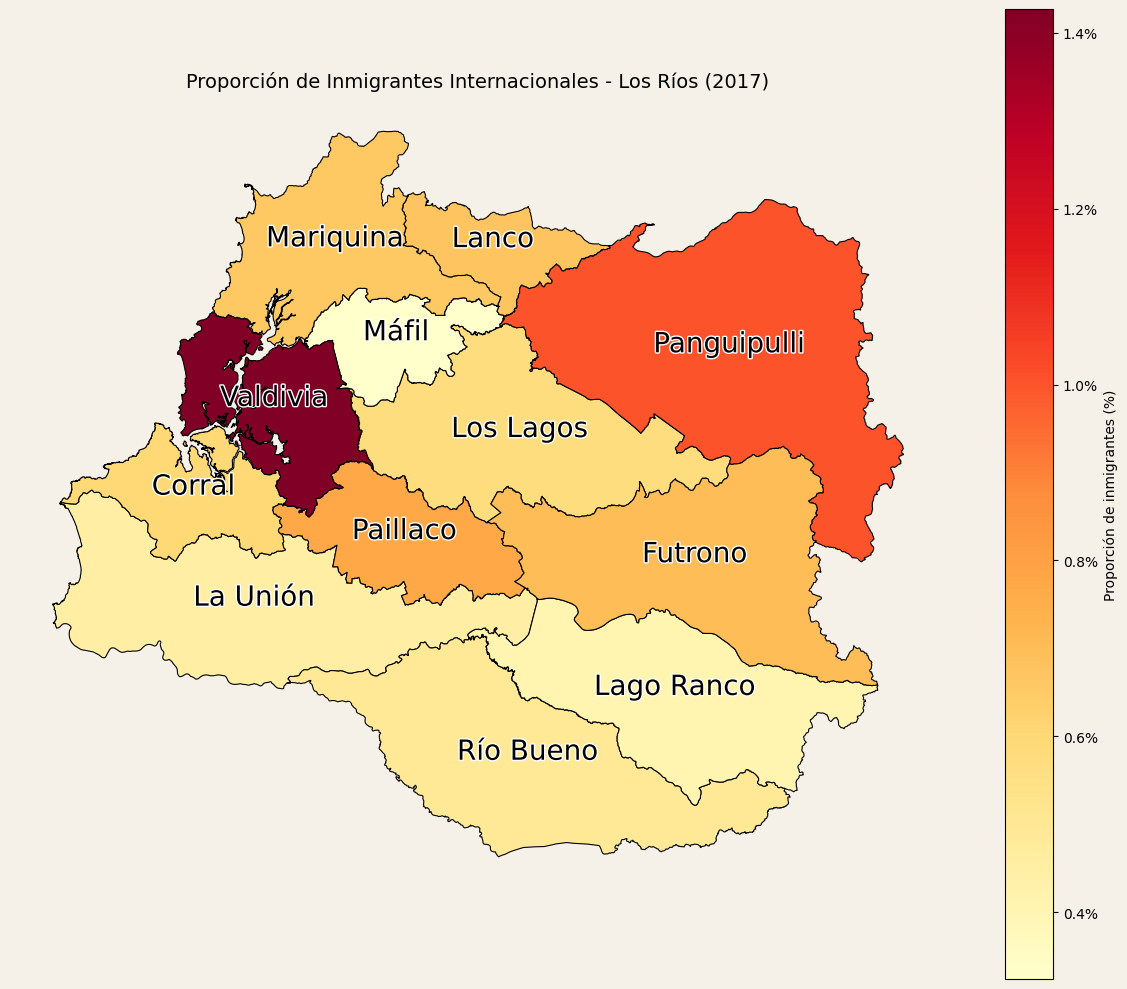

In [2]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib import patheffects
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import matplotlib.cm as cm

# ── Migración 2017 ─────────────────────────
df_interna = pd.read_excel("2_2_migracion.xls", sheet_name=3, skiprows=2)
df_interna.rename(columns={
    "NOMBRE REGIÓN \nRESIDENCIA HABITUAL ACTUAL": "Region",
    "NOMBRE COMUNA\nRESIDENCIA HABITUAL ACTUAL": "Comuna",
    "TOTAL POBLACIÓN NACIDA FUERA DEL PAÍS": "Migrantes"
}, inplace=True)

losrios = df_interna[df_interna["Region"] == "LOS RÍOS"].copy()
losrios = losrios[~losrios["GRUPO DE EDAD"].astype(str).str.contains("Total", na=False)]

migrantesComuna = losrios.groupby("Comuna")["Migrantes"].sum().reset_index()
migrantesComuna["Comuna"] = migrantesComuna["Comuna"].str.strip().str.title()

# ── Población 2017 ─────────────────────────
df_poblacion = pd.read_excel("1_1_poblacion.xls", sheet_name=3, skiprows=2)
df_poblacion.rename(columns={
    "NOMBRE REGIÓN": "Region",
    "NOMBRE COMUNA": "Comuna",
    "TOTAL POBLACIÓN EFECTIVAMENTE CENSADA": "Poblacion"
}, inplace=True)

losrios_pob = df_poblacion[df_poblacion["Region"] == "LOS RÍOS"].copy()
losrios_pob = losrios_pob[~losrios_pob["EDAD"].astype(str).str.contains("Total", na=False)]

poblacionComuna = losrios_pob.groupby("Comuna")["Poblacion"].sum().reset_index()
poblacionComuna["Comuna"] = poblacionComuna["Comuna"].str.strip().str.title()

# ── Proporción ─────────────────────────────
datos17 = migrantesComuna.merge(poblacionComuna, on="Comuna", how="left")
datos17["Proporción (%)"] = (datos17["Migrantes"] / datos17["Poblacion"]) * 100

# ── Shapefile ──────────────────────────────
gdf = gpd.read_file("comunas.shp")
los_rios = gdf[gdf["codregion"] == 14].copy()
los_rios["Comuna"] = los_rios["Comuna"].str.strip().str.title()

mapa17 = los_rios.merge(datos17, on="Comuna", how="left")

# ── Graficar ───────────────────────────────
fig, ax = plt.subplots(figsize=(12, 10))
cmap = cm.YlOrRd
norm = Normalize(vmin=mapa17["Proporción (%)"].min(), vmax=mapa17["Proporción (%)"].max())

mapa17.plot(
    column="Proporción (%)",
    ax=ax,
    cmap=cmap,
    norm=norm,
    edgecolor="black",
    linewidth=0.8,
    missing_kwds={"color": "lightgrey", "label": "Sin datos"}
)
# 👇 Fondo beige
fig.patch.set_facecolor("#F5F0E8")
# Etiquetas
for _, row in mapa17.iterrows():
    centroid = row["geometry"].centroid
    ax.annotate(
        row["Comuna"],
        xy=(centroid.x, centroid.y),
        ha="center",
        fontsize=20,
        color="black",
        path_effects=[
            patheffects.withStroke(linewidth=2, foreground="white")
        ]
    )

# Barra de color
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, label="Proporción de inmigrantes (%)")
cbar.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.1f}%"))

ax.set_title("Proporción de Inmigrantes Internacionales - Los Ríos (2017)", fontsize=14)
ax.axis("off")
plt.tight_layout()
plt.show()